# Import Libraries

In [2]:
import sys, os

# Add path to import
sys.path.append(os.path.abspath(".."))

In [3]:
from src.forecasting.utils.libraries_data_handling import pd, np
from src.forecasting.utils.libraries_others import re, os, time, Enum, Optional, gc, pickle, json, ast
from src.forecasting.utils.libraries_plotting import plt
from src.forecasting.utils.libraries_modelling import torch, concatenate, TimeSeries, Scaler, NBEATSModel, plot_contour, plot_optimization_history, plot_param_importances, GaussianLikelihood
from src.forecasting.constants.columns import col_decode, col_encode
from src.forecasting.utils.memory import cleanup
from src.forecasting.constants.enums import ColumnGroup, PeriodList
from src.forecasting.utils.data_split import dataframe_train_valid_test_split
from src.forecasting.models.nbeats_build import nbeats_build
from src.forecasting.models.evaluate_cv_timeseries import evaluate_cv_timeseries
from src.forecasting.models.evaluate_test_timeseries import evaluate_test_timeseries
from src.forecasting.models.nbeats_store_to_excel import nbeats_inference_store_to_excel
from src.forecasting.models.empty_worst_model import empty_worst_model
from src.forecasting.utils.scale_timeseries_per_component import scale_Y_timeseries_per_component, scale_X_timeseries_per_component

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
/home/jovyan/work/3012010008/env_3012010008/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Set Up

In [4]:
GPU = False
# Initialize internal precision of matrix multiplication
if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')
    torch.manual_seed(42)
    GPU = True

# Make dir to store results
work_dir  = '../models/checkpoint_inference_nbeats/'
os.makedirs(work_dir, exist_ok=True)

# Setting number after coma to max 5 digits
np.set_printoptions(suppress=True, precision=5)

/home/jovyan/work/3012010008/env_3012010008/lib/python3.11/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


# Function

In [5]:
def get_targets(df, target_cols=None):
    if target_cols is None:
        target_cols = ['y1', 'y2', 'y3', 'y4', 'y5', 'y6']
    available = [col for col in target_cols if col in df.columns]
    return df[available].astype('float32')

def get_features(df, target_cols=None):
    if target_cols is None:
        target_cols = ['y1','y2','y3','y4','y5','y6']
    available_targets = [col for col in target_cols if col in df.columns]
    return df.drop(columns=available_targets).astype('float32')

def load_dataset_for_inference(
    dataset_type : str,
    valid_size   : float,
    drop_cols    : bool,
    test_size    : float = 0.1,
):
    # ========================= LOAD DATA ========================= #
    # Load actual data
    df_actual = pd.read_csv('../data/processed/past_covariates_noOutliers_5.csv').drop(
        columns=['x1','x2','x3','x4_zero', 'x4_nonzero','x5','x6','x7_sin', 'x7_cos','x8_zero', 'x8_nonzero'])

    # Load past dataset
    if dataset_type == 'sqrt_NoOzon_5':
        prenorm_type = 'sqrt'
        df_past = pd.read_csv(
            '../data/processed/past_covariates_sqrt_transform_NoOzon_5.csv'
        )
        df_actual = df_actual.drop(columns=['y6'])
        
    elif dataset_type == 'sqrt_NoOzon':
        prenorm_type = 'sqrt'
        df_past = pd.read_csv(
            '../data/processed/past_covariates_sqrt_transform_NoOzon.csv'
        )
        df_actual = df_actual.drop(columns=['y6'])

    elif dataset_type == 'sqrt':
        prenorm_type = 'sqrt'
        df_past = pd.read_csv(
            '../data/processed/past_covariates_sqrt_transform_5.csv'
        )

    elif dataset_type == 'no_outliers_noOzon':
        prenorm_type = None
        df_past = pd.read_csv(
            '../data/processed/past_covariates_noOutliers_NoOzon_5.csv'
        )

    elif dataset_type == 'log1p_NoOzon':
        prenorm_type = 'log1p'
        df_past = pd.read_csv(
            '../data/processed/past_covariates_log_transform_NoOzon_5.csv'
        )
        df_actual = df_actual.drop(columns=['y6'])

    elif dataset_type == 'default_noOzon':
        prenorm_type = None
        df_past = pd.read_csv(
            '../data/processed/past_covariates.csv'
        )
        df_actual = df_actual.drop(columns=['y6'])

    else:
        raise ValueError(f'Unknown dataset_type: {dataset_type}')


    # ========================= DATA PREPROCESSING ========================= #
    # Set index
    for name, df in zip(
        ['past','actual'],
        [df_past, df_actual]
    ):
        df['t'] = pd.to_datetime(df['t'])
        df.set_index('t', inplace=True)
        df.sort_index(inplace=True)
        df.asfreq('h')

    ## ========================= LOAD CORRELATION RESULTS ========================= ##
    # Load correlation results
    results_r = pd.read_csv('../data/processed/correlation_scores.csv')

    # Take very low correlation level (0.00 - 0.199) to drop
    dropped_covariates = results_r[results_r['Correlation'] <= 0.2]['Feature'].to_list()

    # Encode drop colomns name
    dropped_covariates = [col_encode[feature] for feature in dropped_covariates]

    # Drop covariates columns
    if drop_cols == True:
        df_past = df_past.drop(columns=['x4_zero', 'x4_nonzero', 'x5', 'x7_sin', 'x7_cos'])

    if 'y6' not in df_past.columns:
        df_actual = df_actual.drop(columns=['y6'], errors='ignore')
        

    ## ========================= DATA SPLIT ========================= ##
    # Split dataset into Y and X
    Y = get_targets(df_past)
    X = get_features(df_past)

    # Split to data train and test
    Y_train, Y_valid, Y_test = dataframe_train_valid_test_split(
        Y, valid_size=valid_size, test_size=test_size
    )

    X_train, X_valid, X_test = dataframe_train_valid_test_split(
        X, valid_size=valid_size, test_size=test_size
    )


    # Change to TimeSeries Dataset
    def to_ts(df):
        return TimeSeries.from_dataframe(
            df, value_cols=df.columns.tolist(), freq='h'
        ).astype('float32')

    Y_train_ts = to_ts(Y_train)
    Y_valid_ts = to_ts(Y_valid)
    Y_test_ts  = to_ts(Y_test)

    X_train_ts = to_ts(X_train)
    X_valid_ts = to_ts(X_valid)
    X_test_ts  = to_ts(X_test)


    ## ========================= NORMALIZATION ========================= ##
    # Initialize X Columns to normalize
    x_normalize_cols = None
    if drop_cols == True:
        x_normalize_cols = ['x1', 'x3', 'x6']
    elif drop_cols == False:
        x_normalize_cols = ['x1', 'x3', 'x5', 'x6']

    # Initialize Y and X scalers
    Y_scaler = Scaler()
    X_scaler = Scaler()

    Y_train_scaled = Y_scaler.fit_transform(Y_train_ts)
    Y_valid_scaled = Y_scaler.transform(Y_valid_ts)
    Y_test_scaled  = Y_scaler.transform(Y_test_ts)

    X_train_scaled = X_scaler.fit_transform(X_train_ts[x_normalize_cols])
    X_valid_scaled = X_scaler.transform(X_valid_ts[x_normalize_cols])
    X_test_scaled  = X_scaler.transform(X_test_ts[x_normalize_cols])

    ## ========================= MERGE TRAIN + VALID ========================= ##
    Y_train_full = Y_train_scaled.append(Y_valid_scaled)
    X_train_full = X_train_scaled.append(X_valid_scaled)

    return (
        df_actual,
        Y_train_full,
        X_train_full,
        Y_train_scaled,
        Y_valid_scaled,
        Y_test_scaled,
        X_train_scaled,
        X_valid_scaled,
        X_test_scaled,
        Y_scaler,
        X_scaler,
        prenorm_type
    )

# Load Best Model

In [6]:
best = pd.read_excel('../reports/nbeats_inference_results.xlsx').sort_values('MAPE_sum')
# best = best[best['n_predict'] == 12].iloc[0] # FOR predict 12 step ahead
best = best[best['n_predict'] == 12].iloc[0] # FOR predict at entire data test
best

timestamp                                      2026-03-08 11:59:20.142000
valid_MAPE_sum                                                  79.636781
MAE_sum                                                         491.45434
MAPE_sum                                                        94.214679
MSE_sum                                                     433579.244392
RMSE_sum                                                       698.807548
dataset_type                                           no_outliers_noOzon
n_predict                                                              12
model_name              optuna_nbeats_typeno_outliers_noOzon_ic24_oc12...
GPU                                                                  True
fit_cost_seconds                                              1228.023183
predict_cost_seconds                                             0.667856
valid_MAPE_y1                                                   15.534073
valid_MAPE_y2                         

In [7]:
# Get params
dataset_type        = str(best['dataset_type'])
n_predict           = int(best['n_predict'])
model_name          = str(best['model_name'])
input_chunk_length  = int(best['input_chunk_length'])
output_chunk_length = int(best['output_chunk_length'])
n_epochs            = int(best['n_epochs'])
batch_size          = int(best['batch_size'])
num_stacks          = int(best['num_stacks'])
num_blocks          = int(best['num_blocks']) 
num_layers          = int(best['num_layers'])
layer_widths        = int(best['layer_widths'])
dropout             = float(best['dropout'])
lr                  = float(best['lr'])
random_state        = int(best['random_state'])
validation_split    = float(best['validation_split'])
stride              = int(best['stride'])
Y_col_list          = ast.literal_eval(best['Y_col_list'])
X_col_list          = ast.literal_eval(best['X_col_list'])
add_encoders        = json.loads(best['add_encoders']) if pd.notna(best['add_encoders']) else None

# Load Processed Dataset

In [8]:
# Load dataset
(
    df_actual,
    Y_train_full,
    X_train_full,
    Y_train_scaled,
    Y_valid_scaled,
    Y_test_scaled,
    X_train_scaled,
    X_valid_scaled,
    X_test_scaled,
    Y_scaler,
    X_scaler,
    prenorm_type
) = load_dataset_for_inference(
        dataset_type = dataset_type,
        valid_size   = validation_split,
        drop_cols    = True,
    )

print('Y_train_full cols: ', Y_train_full.components)
print('X_train_full cols: ', X_train_full.components)

Y_train_full cols:  Index(['y1', 'y2', 'y3', 'y4', 'y5'], dtype='object')
X_train_full cols:  Index(['x1', 'x3', 'x6'], dtype='object')


# Re-Train Model

In [ ]:
fit_start = time.time()
model = nbeats_build(
    Y_train             = Y_train_scaled,
    X_train             = X_train_scaled,
    Y_valid             = Y_valid_scaled,
    X_valid             = X_valid_scaled,
    input_chunk_length  = input_chunk_length,
    output_chunk_length = output_chunk_length,
    n_epochs            = n_epochs,
    batch_size          = batch_size,
    num_stacks          = num_stacks,
    num_blocks          = num_blocks,
    num_layers          = num_layers,
    layer_widths        = layer_widths,
    dropout             = dropout,
    add_encoders        = add_encoders,
    model_name          = model_name,
    work_dir            = work_dir,
    lr                  = lr,
    random_state        = random_state
)
fit_cost_seconds = time.time() - fit_start

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 25.1 M | train
-------------------------------------------------------------
25.1 M    Trainable params
3.7 K     Non-trainable params
25.1 M    Total params
100.375   Total estimated model params size (MB)
412       Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 1271/1271 [03:05<00:00,  6.85it/s, train_loss=-0.70]  
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 1271/1271 [03:06<00:00,  6.81it/s, train_loss=-0.884, val_loss=-0.41]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 1271/1271 [03:06<00:00,  6.81it/s, train_loss=-0.753, val_loss=-0.476]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 1271/1271 [03:06<00:00,  6.82it/s, train_loss=-0.95, val_loss=-0.499] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 1271/1271 [03:06<00:00,  6.82it/s, train_loss=-0.846, val_loss=-0.475]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 1271/1271 [03:06<00:00,  6.81it/s, train_loss=-0.968, val_loss=-0.428]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 1271/1271 [03:06<00:00,  6.83it/s, train_loss=-0.957, val_loss=-0.455]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 7: 100%|██

# Cross Validation

In [10]:
cv_test = model.historical_forecasts(
    series            = Y_train_scaled.append(Y_valid_scaled),
    past_covariates   = X_train_scaled.append(X_valid_scaled),
    start             = Y_train_scaled.get_timestamp_at_point(input_chunk_length),
    forecast_horizon  = output_chunk_length,
    stride            = output_chunk_length,
    retrain           = False,
    last_points_only  = False,
)

In [11]:
# Validation Evaluate
mape_cv = evaluate_cv_timeseries(
    forecasts    = cv_test,
    scaler       = Y_scaler,
    df_actual    = df_actual,
    prenorm_type = prenorm_type
)
    
# Save MAPE validation results
valid_MAPE_sum     = sum(mape_cv.values())

print(f'\n💹 MAPE_sum : {valid_MAPE_sum}')
print(f'🧠 MAPE CV: {mape_cv}\n')

15.673321
16.305052
16.673992
15.952354
15.556016

💹 MAPE_sum : 80.16073513031006
🧠 MAPE CV: {'y1': 15.673321, 'y2': 16.305052, 'y3': 16.673992, 'y4': 15.952354, 'y5': 15.556016}



# Predict

In [12]:
X_past   = X_train_full.append(X_test_scaled)

predict_start = time.time()
forecasts = model.predict(
    n                 = n_predict,
    series            = Y_train_full,
    past_covariates   = X_past,
    verbose           = False,
    n_jobs            = 1,
    random_state      = random_state,
)
predict_cost_seconds = time.time() - predict_start

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


# Backtesting

In [13]:
Y  = Y_train_full.append(Y_test_scaled)

backtesting = model.historical_forecasts(
    series=Y,
    past_covariates=X_past,
    start=Y_test_scaled.start_time(),
    forecast_horizon=12,
    stride=1,
    retrain=False,
    verbose=False
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


# Evaluate Predict

In [14]:
# Evaluate
mse_test, rmse_test, mae_test, mape_test = evaluate_test_timeseries(
    forecasts    = forecasts,
    scaler       = Y_scaler,
    df_actual    = df_actual,
    prenorm_type = prenorm_type
)

# Save evaluation results
MAE_sum  = sum(mae_test.values())
MAPE_sum = sum(mape_test.values())
MSE_sum  = sum(mse_test.values())
RMSE_sum = sum(rmse_test.values())

print(f'\n💹 MAE_sum : {MAE_sum}')
print(f'🧠 MAPE test: {mae_test}\n')
print(f'\n💹 MAPE_sum : {MAPE_sum}')
print(f'🧠 MAPE test: {mape_test}\n')
print(f'\n💹 MSE_sum : {MSE_sum}')
print(f'🧠 MSE test: {mse_test}\n')
print(f'\n💹 RMSE_sum : {RMSE_sum}')
print(f'🧠 RMSE test: {rmse_test}\n')


💹 MAE_sum : 678.4827876091003
🧠 MAPE test: {'y1': 5.9223466, 'y2': 13.772714, 'y3': 648.8975, 'y4': 5.808346, 'y5': 4.0818596}


💹 MAPE_sum : 103.40725040435791
🧠 MAPE test: {'y1': 10.269308, 'y2': 26.03247, 'y3': 35.225334, 'y4': 13.566165, 'y5': 18.313972}


💹 MSE_sum : 589856.3203811646
🧠 MSE test: {'y1': 68.19625, 'y2': 251.76605, 'y3': 589445.56, 'y4': 64.381996, 'y5': 26.413582}


💹 RMSE_sum : 805.042094707489
🧠 RMSE test: {'y1': 8.258102, 'y2': 15.867138, 'y3': 767.7536, 'y4': 8.023839, 'y5': 5.1394143}



# Evaluate Backtesting

In [15]:
# Evaluate
mse_test2, rmse_test2, mae_test2, mape_test2 = evaluate_test_timeseries(
    forecasts    = backtesting,
    scaler       = Y_scaler,
    df_actual    = df_actual,
    prenorm_type = prenorm_type
)

# Save evaluation results
MAE_sum2  = sum(mse_test2.values())
MAPE_sum2 = sum(rmse_test2.values())
MSE_sum2  = sum(mae_test2.values())
RMSE_sum2 = sum(mape_test2.values())

print(f'\n💹 MAE_sum : {MAE_sum2}')
print(f'🧠 MAPE test: {mae_test2}\n')
print(f'\n💹 MAPE_sum : {MAPE_sum2}')
print(f'🧠 MAPE test: {mape_test2}\n')
print(f'\n💹 MSE_sum : {MSE_sum2}')
print(f'🧠 MSE test: {mse_test2}\n')
print(f'\n💹 RMSE_sum : {RMSE_sum2}')
print(f'🧠 RMSE test: {rmse_test2}\n')


💹 MAE_sum : 576539.2860984802
🧠 MAPE test: {'y1': 15.531187, 'y2': 18.383398, 'y3': 547.3691, 'y4': 15.294876, 'y5': 5.7657423}


💹 MAPE_sum : 832.3207879066467
🧠 MAPE test: {'y1': 41.768635, 'y2': 46.447605, 'y3': 52.46234, 'y4': 39.652977, 'y5': 46.050877}


💹 MSE_sum : 602.3442831039429
🧠 MSE test: {'y1': 430.72733, 'y2': 608.5426, 'y3': 575005.0, 'y4': 434.9096, 'y5': 60.106564}


💹 RMSE_sum : 226.3824348449707
🧠 RMSE test: {'y1': 20.753971, 'y2': 24.668655, 'y3': 758.29083, 'y4': 20.854486, 'y5': 7.7528424}



# Save to Excel

## Predict Results

In [16]:
# Inverse scaling & prenorm transform per target
predict = Y_scaler.inverse_transform(forecasts)

if prenorm_type is None:
    pass
elif prenorm_type == 'sqrt':
    predict = predict ** 2
elif prenorm_type == 'log1p':
    predict = predict.map(np.expm1)

# Extact actual and prediction
start_pred  = predict.start_time()
end_pred    = predict.end_time()
actual_pred = df_actual.loc[start_pred:end_pred]

actual_pred = TimeSeries.from_dataframe(
    actual_pred, value_cols=actual_pred.columns.tolist(), freq='h'
).astype('float32')

# Save prediction on excel
pred_df = predict.to_dataframe()
pred_df.columns = [f"{c}_pred" for c in pred_df.columns]

actual_df = df_actual.loc[start_pred:end_pred].copy()
actual_df.columns = [f"{c}_actual" for c in actual_df.columns]

# Merge
result_df = actual_df.join(pred_df)

# Save to excel
result_df.to_excel('../reports/nbeats_prediction_results.xlsx')

## Backcast Results

In [17]:
# Inverse scaling & prenorm transform per target
backcast = Y_scaler.inverse_transform(backtesting)

if prenorm_type is None:
    pass
elif prenorm_type == 'sqrt':
    backcast = backcast ** 2
elif prenorm_type == 'log1p':
    backcast = backcast.map(np.expm1)

# Extact actual and prediction
start_backcast  = backcast.start_time()
end_backcast    = backcast.end_time()
actual_backcast = df_actual.loc[start_backcast:end_backcast]

actual_backcast = TimeSeries.from_dataframe(
    actual_backcast, value_cols=actual_backcast.columns.tolist(), freq='h'
).astype('float32')

# Save prediction on excel
backcast_df = backcast.to_dataframe()
backcast_df.columns = [f"{c}_pred" for c in backcast_df.columns]

actual_df = df_actual.loc[start_backcast:end_backcast].copy()
actual_df.columns = [f"{c}_actual" for c in actual_df.columns]

# Merge
result_df = actual_df.join(backcast_df)

# Save to excel
result_df.to_excel('../reports/nbeats_backcast_results.xlsx')

# Interpretability

In [18]:
# Initialize interpretability path

interpretability_path = '../reports/figures/nbeats'
os.makedirs(interpretability_path, exist_ok=True)

## Line Plot

## Line Plot for Predict

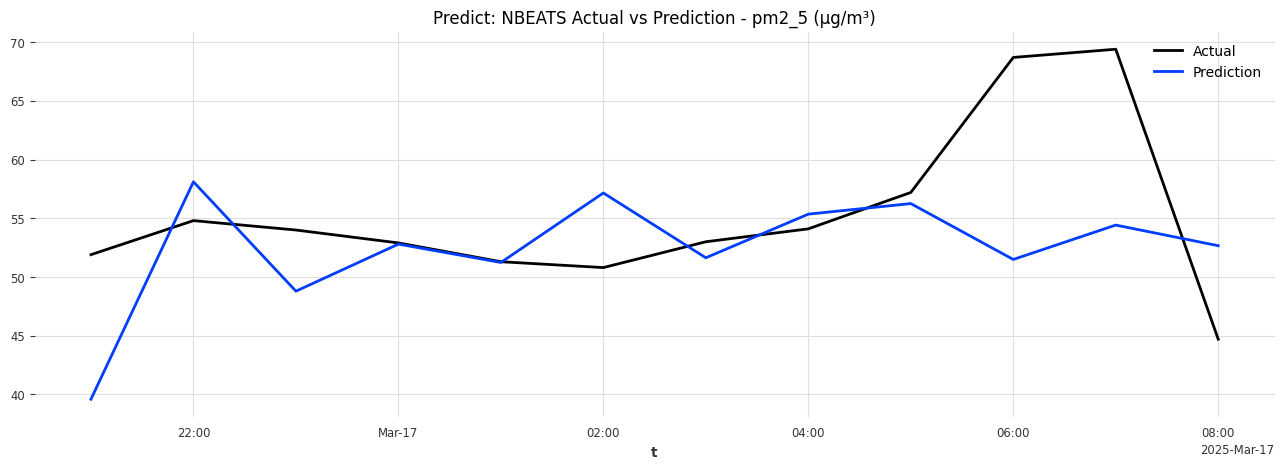

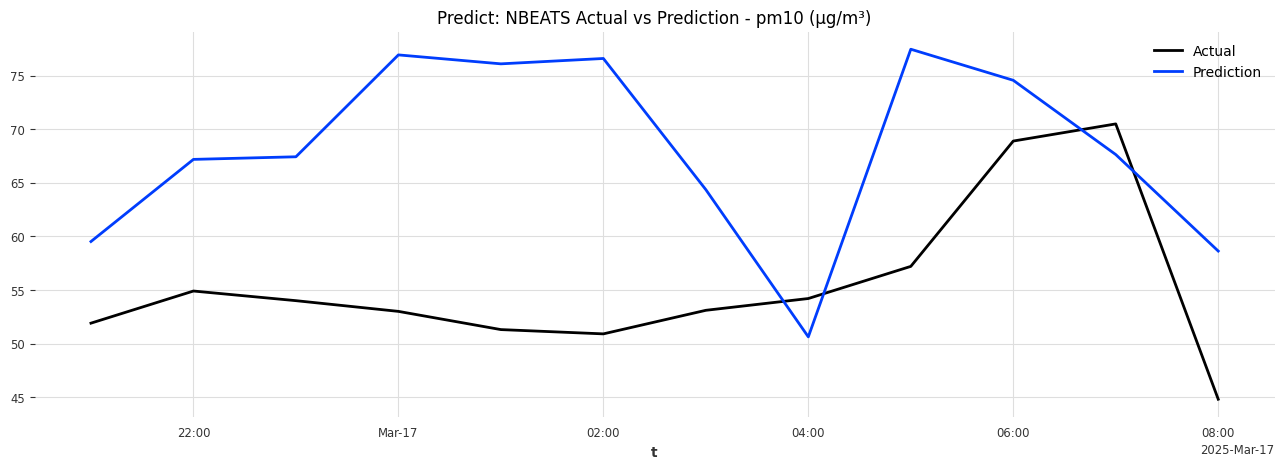

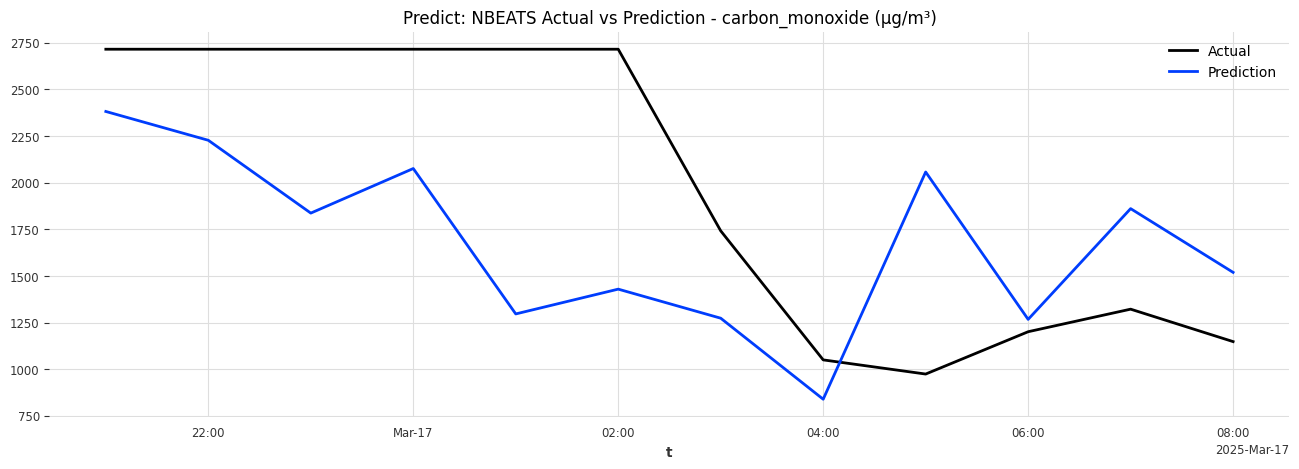

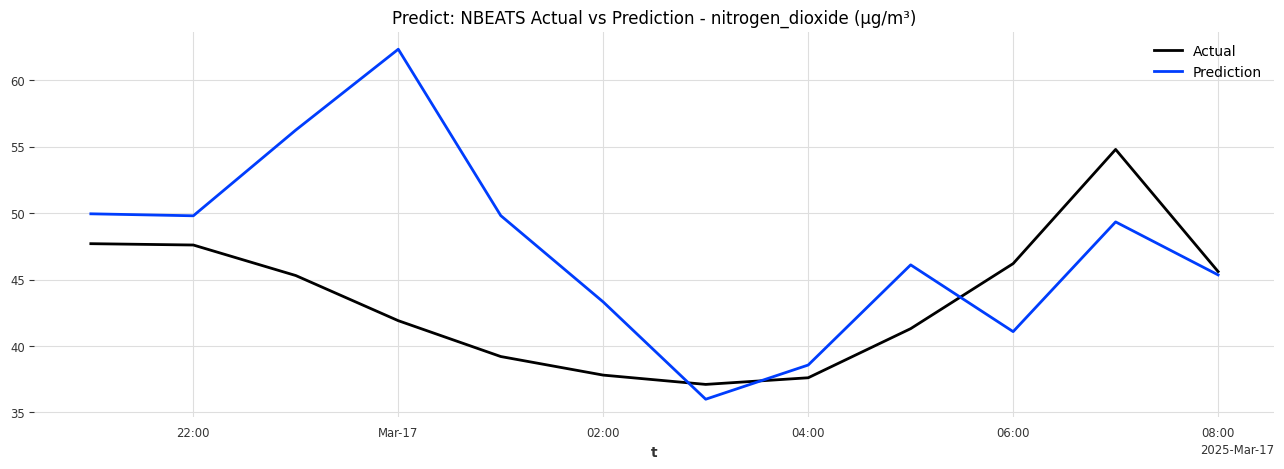

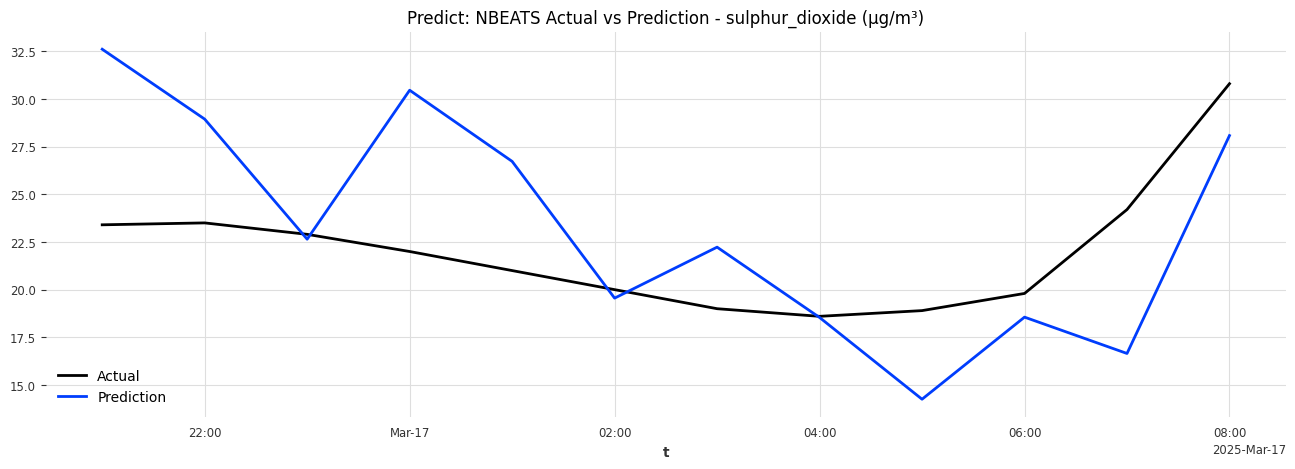

In [19]:
# Line plot for predict
for col in actual_pred.components:
    
    plt.figure(figsize=(16,5))
    
    actual_pred[col].plot(label="Actual")
    predict[col].plot(label="Prediction")
    
    plt.title(f"Predict: NBEATS Actual vs Prediction - {col_decode[col]}")
    plt.legend()
    plt.savefig(f"../reports/figures/nbeats/predict_{col}.png", dpi=300)
    plt.show()

## Line Plot for Backtesting

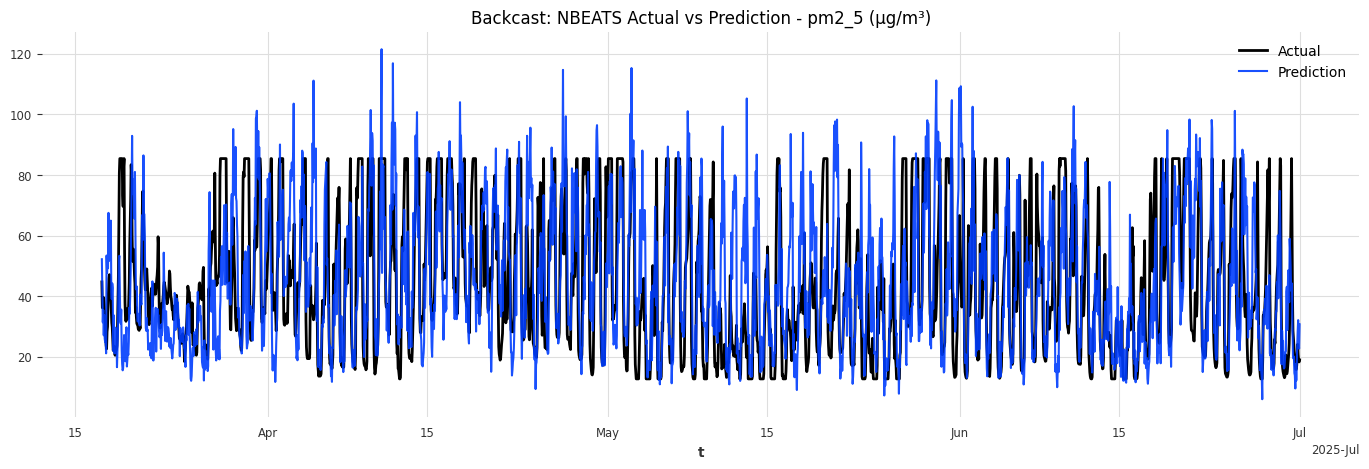

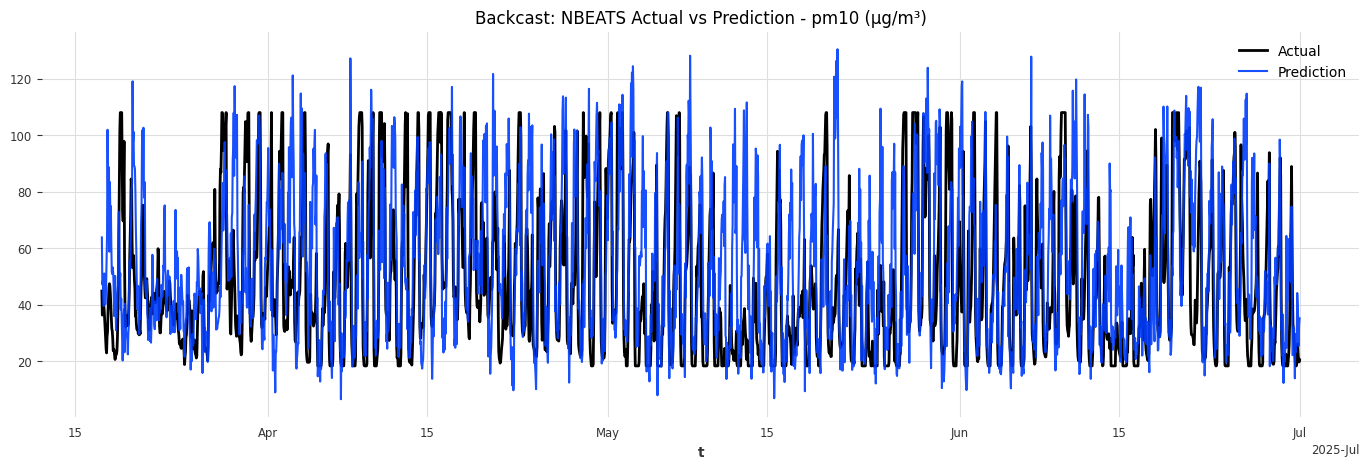

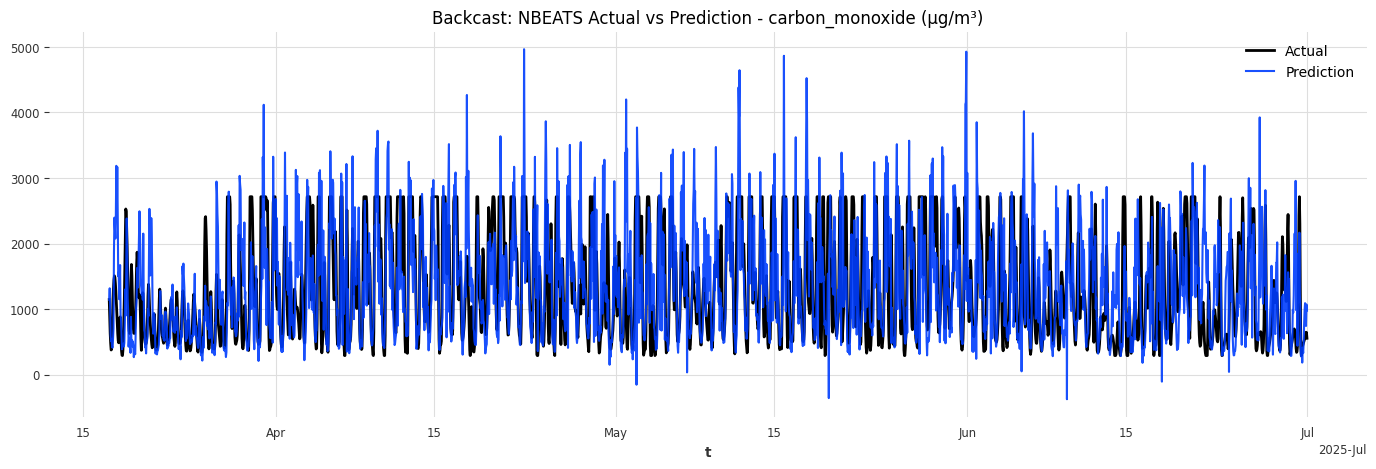

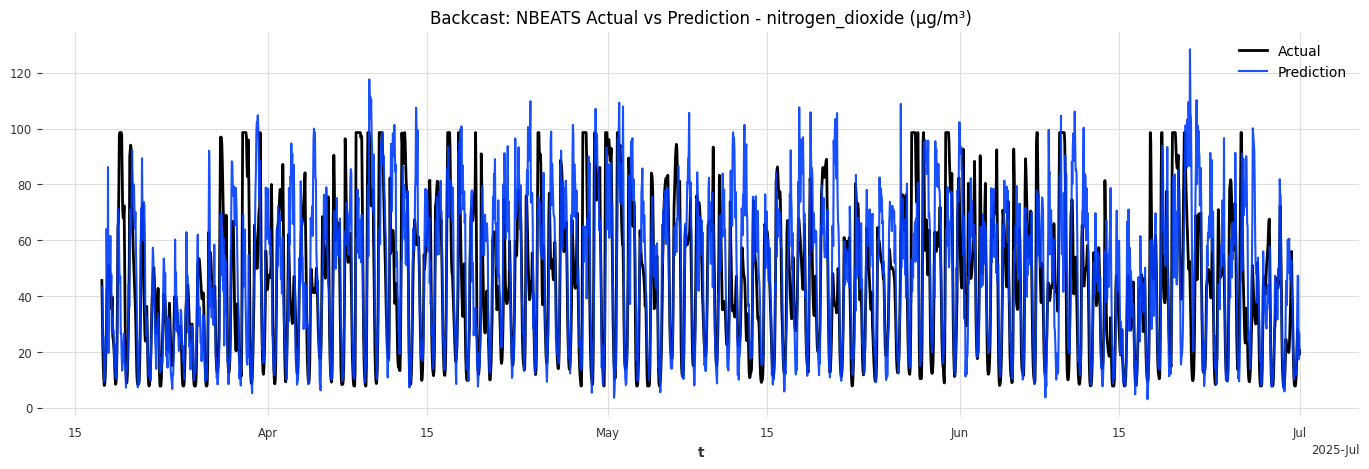

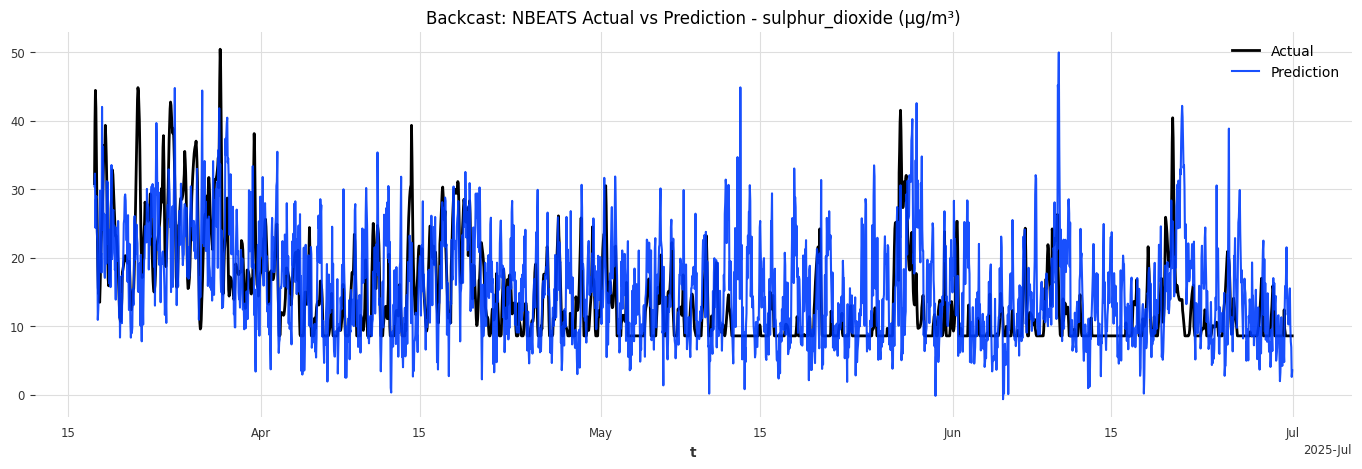

In [20]:
# Line plot for predict
for col in actual_backcast.components:
    
    plt.figure(figsize=(17,5))
    
    actual_backcast[col].plot(label="Actual", linewidth=2, alpha=1)
    backcast[col].plot(label="Prediction", linewidth=1.5, alpha=0.9)
    
    plt.title(f"Backcast: NBEATS Actual vs Prediction - {col_decode[col]}")
    plt.legend()
    plt.savefig(f"../reports/figures/nbeats/backcast_{col}.png", dpi=300)
    plt.show()

# Predict the Future

In [21]:
predict_start = time.time()
forecasts_future = model.predict(
    n                 = output_chunk_length,
    series            = Y,
    past_covariates   = X_past,
    verbose           = False,
    n_jobs            = 1,
    random_state      = random_state,
)
predict_cost_seconds = time.time() - predict_start

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [22]:
# Inverse scaling & prenorm transform per target
pred_future = Y_scaler.inverse_transform(forecasts_future)

if prenorm_type is None:
    pass
elif prenorm_type == 'sqrt':
    pred_future = pred_future ** 2
elif prenorm_type == 'log1p':
    pred_future = pred_future.map(np.expm1)

In [23]:
# Save prediction on excel
pred_future_df = pred_future.to_dataframe()
pred_future_df.columns = [f"{c}_future_pred" for c in pred_future_df.columns]

# Save to excel
pred_future_df.to_excel('../reports/nbeats_future_prediction_results.xlsx')

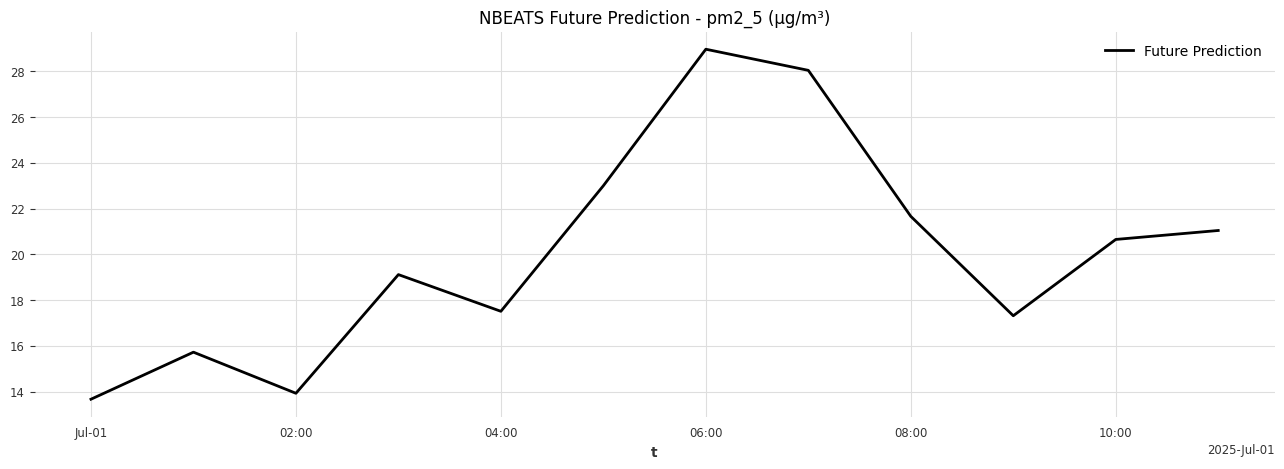

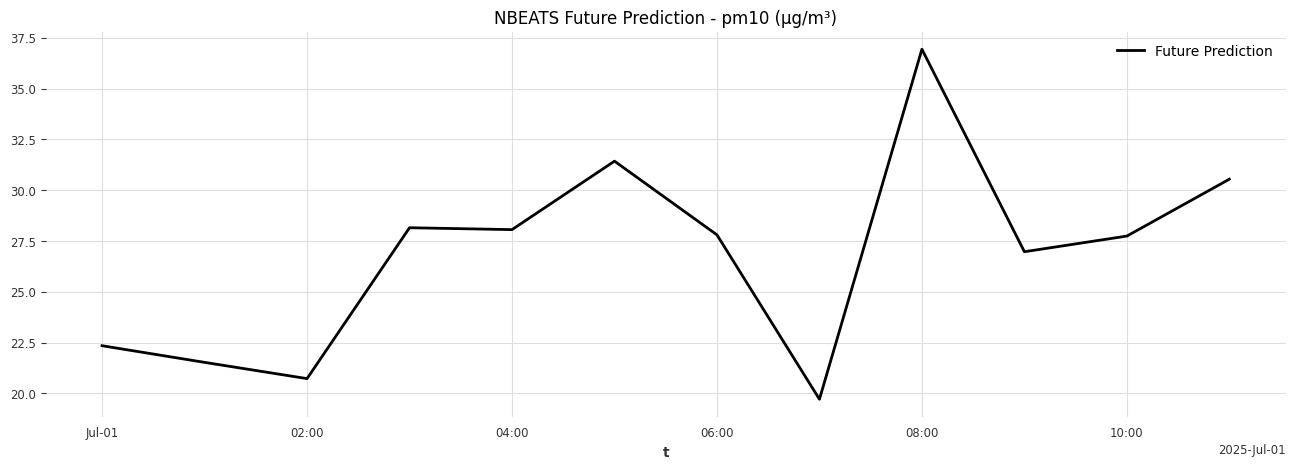

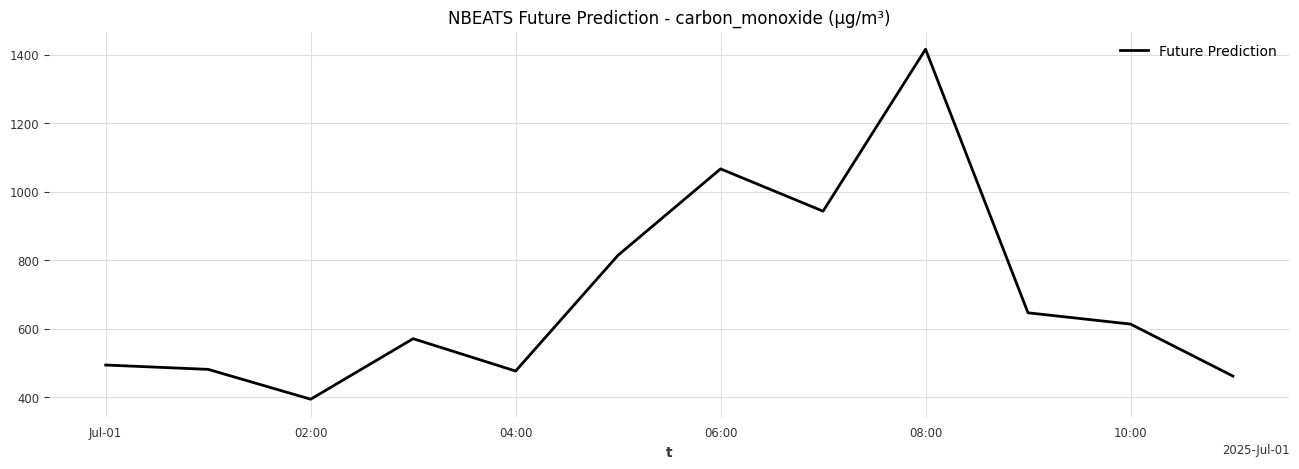

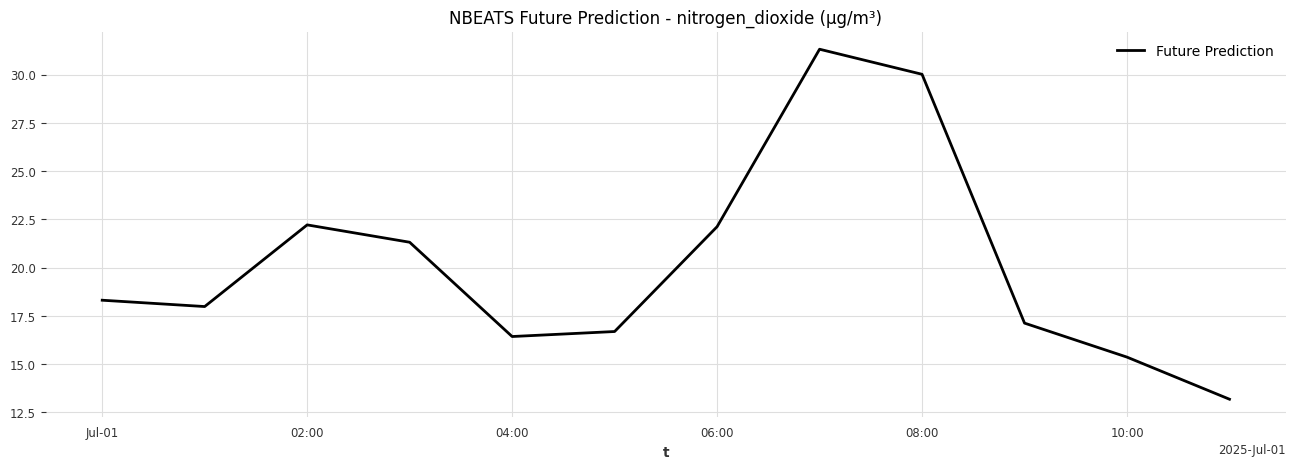

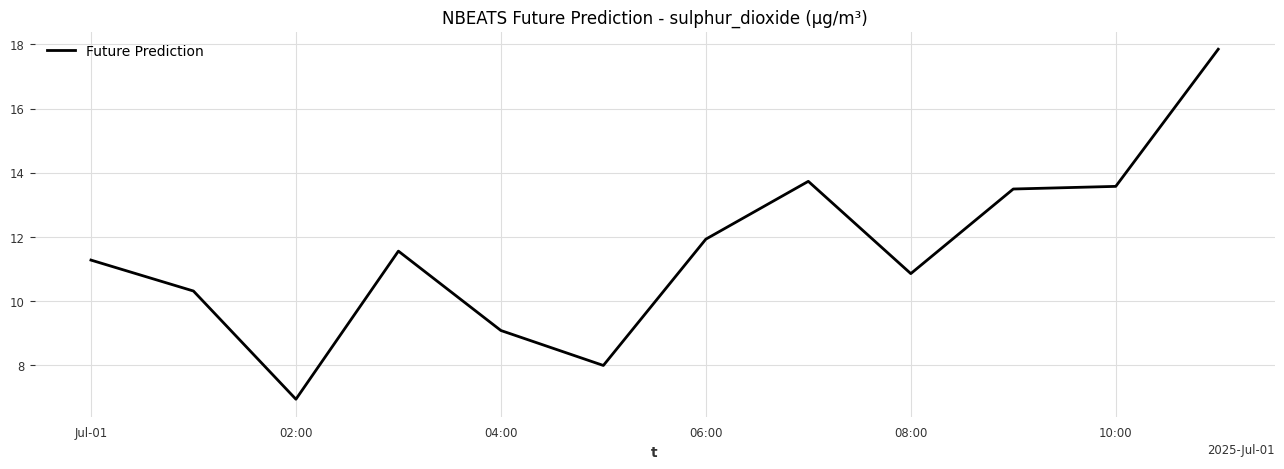

In [24]:
# Line plot for predict
for col in actual_pred.components:
    
    plt.figure(figsize=(16,5))
    pred_future[col].plot(label="Future Prediction")
    
    plt.title(f"NBEATS Future Prediction - {col_decode[col]}")
    plt.legend()
    plt.savefig(f'../reports/figures/nbeats/future_predict_{col}.png', dpi=300)
    plt.show()